# **Controle de Velocidade de um Carro 🚗**

**Ideia:** Simula um controle de cruzeiro adaptativo (ACC) com três entradas,
considerando segurança (distância + velocidade relativa) e conforto (meta de velocidade).

* **Entradas:**
    - Distância do carro à frente (Perto, Média, Longe)
    - Erro de Velocidade: `v_alvo − v_atual` (Negativo, Zero, Positivo)
    - Velocidade Relativa: `v_frente − v_atual` (Aproximando, Acompanhando, Afastando)

* **Saída:**
    - Ação (-100 a 100) — Frear, Manter, Acelerar

# **Variáveis Linguísticas**

**Entradas**

* **Distância** (0 a 100 m) — Trapezoidal / Triangular (Pode ser Gaussiana) / Trapezoidal
    - Perto  → trapmf (0, 0, 20, 50)
    - Média  → trimf  (30, 50, 70)
    - Longe  → trapmf (50, 80, 100, 100)

* **Erro de Velocidade** `v_alvo − v_atual` (−60 a 60 km/h) — Trapezoidal / Triangular / Trapezoidal
    - Negativo (acima da meta) → trapmf (−100, −100, −10, 0)
    - Zero    (na meta)        → trimf  (−10, 0, 10)
    - Positivo (abaixo da meta)→ trapmf (0, 10, 100, 100)

* **Velocidade Relativa** `v_frente − v_atual` (−100 a 100 km/h) — Trapezoidal / Triangular / Trapezoidal
    - Aproximando (risco de colisão) → trapmf (−100, −100, −15, 0)
    - Acompanhando (mesma velocidade)→ trimf  (−15, 0, 15)
    - Afastando (via livre)          → trapmf (0, 15, 100, 100)

**Saída** — Triangular
* **Ação** (−100 a 100)
    - Frear    → trimf (−100, −100, 0)
    - Manter   → trimf (−20, 0, 20)
    - Acelerar → trimf (0, 100, 100)

# **Regras Fuzzy**

|     | Distância | Vel. Relativa | Erro Vel. | Ação     | Prioridade |
|-----|-----------|---------------|-----------|----------|------------|
| R1  | Perto     | Aproximando   | —         | Frear    | 🔴 Alta    |
| R2  | Perto     | Acompanhando  | —         | Frear    | 🔴 Alta    |
| R3  | Perto     | Afastando     | —         | Manter   | 🔴 Alta    |
| R4  | Média     | Aproximando   | —         | Frear    | 🟡 Média   |
| R5  | Média     | Acompanhando  | —         | Manter   | 🟡 Média   |
| R6  | Média     | Afastando     | Positivo  | Acelerar | 🟡 Média   |
| R7  | Média     | Afastando     | Negativo  | Frear    | 🟡 Média   |
| R8  | Longe     | —             | Positivo  | Acelerar | 🟢 Baixa   |
| R9  | Longe     | —             | Zero      | Manter   | 🟢 Baixa   |
| R10 | Longe     | —             | Negativo  | Frear    | 🟢 Baixa   |

**Lógica AND = operador mínimo (Mamdani)**


In [1]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

Estabelecendo a relação entre as varáveis:

In [3]:
distancia = ctrl.Antecedent(np.arange(0, 101, 1), 'distancia')

# Erro = Velocidade Alvo - Velocidade Atual (v_Alvo - v_Atual)
erro_velocidade = ctrl.Antecedent(np.arange(-60, 61, 1), 'erro_velocidade')

# Relativa = Vel. Carro da Frente - Minha vel. (v_carroFrente - v_Atual)
velocidade_relativa = ctrl.Antecedent(np.arange(-100, 101, 1), 'velocidade_relativa')

acao = ctrl.Consequent(np.arange(-100, 101, 1), 'acao')

Seguindo o fluxo de: fuzzificação --> avaliação das regras --> implicação --> agregação --> defuzzificação

Fuzzificação: converter os valores numéricos de entrada (EX: erro: Alvo 100 - Atual 95 = 5, carro_frente = 80km/h -> velocidade_relativa = Frente 80 - Minha 95 = -10) em graus de pertinência.

In [4]:
# DISTÂNCIA
distancia['perto'] = fuzz.trapmf(distancia.universe, [0, 0, 20, 50])
distancia['media'] = fuzz.trimf(distancia.universe, [30, 50, 70])
distancia['longe'] = fuzz.trapmf(distancia.universe, [50, 80, 100, 100])

# ERRO DE VELOCIDADE
# Negativo: O meu carro está acima do limite (Precisa de reduzir)
erro_velocidade['negativo'] = fuzz.trapmf(erro_velocidade.universe, [-100, -100, -10, 0])
# Zero: O meu carro está na velocidade alvo (Manter))
erro_velocidade['zero'] = fuzz.trimf(erro_velocidade.universe, [-10, 0, 10])
# Positivo: O meu carro está abaixo do limite (Pode acelerar)
erro_velocidade['positivo'] = fuzz.trapmf(erro_velocidade.universe, [0, 10, 100, 100])

# VELOCIDADE RELATIVA
# Aproximando: O carro da frente está mais lento do que eu (Risco de colisão)
velocidade_relativa['aproximando'] = fuzz.trapmf(velocidade_relativa.universe, [-100, -100, -15, 0])
# Acompanhando: Estamos à mesma velocidade
velocidade_relativa['acompanhando'] = fuzz.trimf(velocidade_relativa.universe, [-15, 0, 15])
# Afastando: O carro da frente está indo mais rápido
velocidade_relativa['afastando'] = fuzz.trapmf(velocidade_relativa.universe, [0, 15, 100, 100])

# AÇÃO
acao['frear'] = fuzz.trimf(acao.universe, [-100, -100, 0])
acao['manter'] = fuzz.trimf(acao.universe, [-20, 0, 20])
acao['acelerar'] = fuzz.trimf(acao.universe, [0, 100, 100])

Avaliação das Regras: aplicar os operadores lógicos (AND = Mínimo) ou (OR = Máximo).

In [5]:
# Prioridade 1: Risco (Perto) - Ignora a meta de alvo km/h
rule1 = ctrl.Rule(distancia['perto'] & velocidade_relativa['aproximando'], acao['frear'])
rule2 = ctrl.Rule(distancia['perto'] & velocidade_relativa['acompanhando'], acao['frear']) # Continua perto, melhor diminuir
rule3 = ctrl.Rule(distancia['perto'] & velocidade_relativa['afastando'], acao['manter'])

# Prioridade 2: Distância Média
rule4 = ctrl.Rule(distancia['media'] & velocidade_relativa['aproximando'], acao['frear'])
rule5 = ctrl.Rule(distancia['media'] & velocidade_relativa['acompanhando'], acao['manter'])
# Se o trânsito está a fluir (afastar), tentamos alcançar a meta de velocidade
rule6 = ctrl.Rule(distancia['media'] & velocidade_relativa['afastando'] & erro_velocidade['positivo'], acao['acelerar'])
rule7 = ctrl.Rule(distancia['media'] & velocidade_relativa['afastando'] & erro_velocidade['negativo'], acao['frear'])

# Prioridade 3: Pista Livre (Manter no alvo km/h)
rule8 = ctrl.Rule(distancia['longe'] & erro_velocidade['positivo'], acao['acelerar'])
rule9 = ctrl.Rule(distancia['longe'] & erro_velocidade['zero'], acao['manter'])
rule10 = ctrl.Rule(distancia['longe'] & erro_velocidade['negativo'], acao['frear'])

Estabelecendo o sistema em si:

In [6]:
sistema_controle = ctrl.ControlSystem([
    rule1, rule2, rule3, rule4, rule5, 
    rule6, rule7, rule8, rule9, rule10
])

simulador = ctrl.ControlSystemSimulation(sistema_controle)

Implicação: cortar a altura do gráfico da função de pertinencia de saída usando a força da regra(Mínimo)

Agregação: juntar todas as figuras cortadas em uma única figura(Máximo)

In [7]:
velocidade_alvo = 100
velocidade_atual = 95
velocidade_frente = 80
dist_val = 80

# Matemática dos sensores
erro_val = velocidade_alvo - velocidade_atual                
vel_relativa_val = velocidade_frente - velocidade_atual     

# Aplica as entradas no simulador
simulador.input['distancia'] = dist_val
simulador.input['erro_velocidade'] = erro_val
simulador.input['velocidade_relativa'] = vel_relativa_val

# Executa o sistema fuzzy
simulador.compute()

Defuzzificação: transformar a área agregada num único número exato para o carro saber o quanto deve travar ou acelerar (Cálculo do Centróide).

    - por padrão, quando o foi criada "acao = ctrl.Consequent(...)", a biblioteca configurou o método de defuzzificação como 'centroid'. Ao pedir o "output['acao']" a biblioteca calcula o centro de gravidade daquela figura geométrica gerada na Agregação e devolve um número com casas decimais.

In [8]:
acao_val = simulador.output['acao']

**Exibindo graficamente o teste realizado:**

C:\Users\nasci\AppData\Roaming\Python\Python314\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


DADOS DOS SENSORES 
Velocidade Atual do Carro: 95 km/h (Meta: 100 km/h)
Velocidade do Carro da Frente: 80 km/h
Distância: 80 m
Erro de Velocidade Calculado: 5 km/h
Velocidade Relativa Calculada: -15 km/h

 DECISÃO DO SISTEMA
Ação Final (Saída): 44.68% do pedal


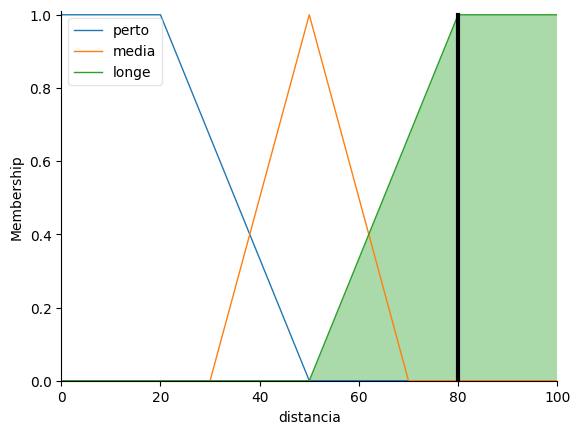

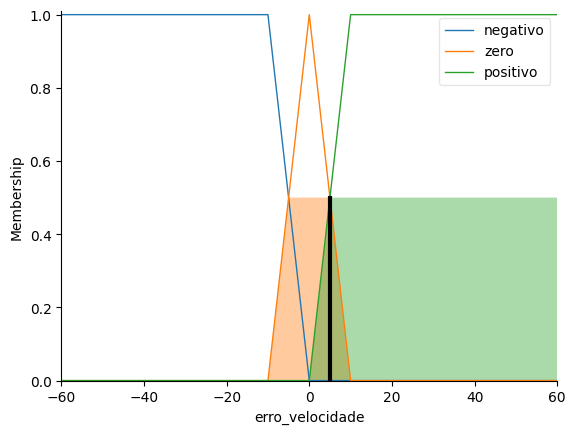

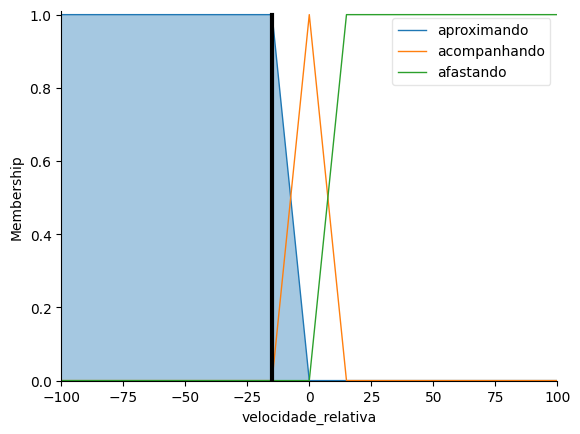

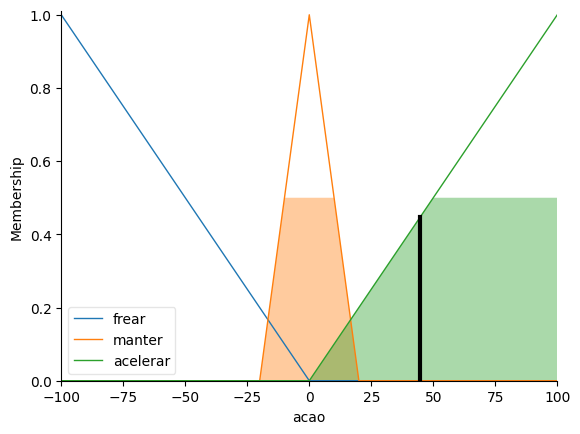

In [9]:
distancia.view(sim=simulador)
erro_velocidade.view(sim=simulador)
velocidade_relativa.view(sim=simulador)
acao.view(sim=simulador)

print(f"DADOS DOS SENSORES ")
print(f"Velocidade Atual do Carro: {velocidade_atual} km/h (Meta: {velocidade_alvo} km/h)")
print(f"Velocidade do Carro da Frente: {velocidade_frente} km/h")
print(f"Distância: {dist_val} m")
print(f"Erro de Velocidade Calculado: {erro_val} km/h")
print(f"Velocidade Relativa Calculada: {vel_relativa_val} km/h")
print(f"\n DECISÃO DO SISTEMA")
print(f"Ação Final (Saída): {acao_val:.2f}% do pedal")

**Calculando os graus de pertinencia do teste realizado:**

In [10]:

#PERTINÊNCIA (ENTRADAS)

# pertinencia da distancia
mu_perto = fuzz.interp_membership(distancia.universe, distancia['perto'].mf, dist_val)
mu_media = fuzz.interp_membership(distancia.universe, distancia['media'].mf, dist_val)
mu_longe = fuzz.interp_membership(distancia.universe, distancia['longe'].mf, dist_val)

# pertinencia do erro de velocidade
mu_erro_neg = fuzz.interp_membership(erro_velocidade.universe, erro_velocidade['negativo'].mf, erro_val)
mu_erro_zero = fuzz.interp_membership(erro_velocidade.universe, erro_velocidade['zero'].mf, erro_val)
mu_erro_pos = fuzz.interp_membership(erro_velocidade.universe, erro_velocidade['positivo'].mf, erro_val)

# pertinencia da velocidade relativa
mu_aprox = fuzz.interp_membership(velocidade_relativa.universe, velocidade_relativa['aproximando'].mf, vel_relativa_val)
mu_acomp = fuzz.interp_membership(velocidade_relativa.universe, velocidade_relativa['acompanhando'].mf, vel_relativa_val)
mu_afast = fuzz.interp_membership(velocidade_relativa.universe, velocidade_relativa['afastando'].mf, vel_relativa_val)

print("PERTINÊNCIA DAS ENTRADAS")

print(f"\n   DISTÂNCIA (Valor lido: {dist_val} m)")
print(f"   - Perto: {mu_perto * 100:05.2f}%")
print(f"   - Média: {mu_media * 100:05.2f}%")
print(f"   - Longe: {mu_longe * 100:05.2f}%")

print(f"\n   ERRO DE VELOCIDADE (Valor calculado: {erro_val} km/h)")
print(f"   - Negativo (Acima da meta) : {mu_erro_neg * 100:05.2f}%")
print(f"   - Zero (Na meta exata)     : {mu_erro_zero * 100:05.2f}%")
print(f"   - Positivo (Abaixo da meta): {mu_erro_pos * 100:05.2f}%")

print(f"\n   VELOCIDADE RELATIVA (Valor calculado: {vel_relativa_val} km/h)")
print(f"   - Aproximando do obstáculo : {mu_aprox * 100:05.2f}%")
print(f"   - Acompanhando             : {mu_acomp * 100:05.2f}%")
print(f"   - Afastando / Via Livre    : {mu_afast * 100:05.2f}%")
print("-" * 47)

PERTINÊNCIA DAS ENTRADAS

   DISTÂNCIA (Valor lido: 80 m)
   - Perto: 00.00%
   - Média: 00.00%
   - Longe: 100.00%

   ERRO DE VELOCIDADE (Valor calculado: 5 km/h)
   - Negativo (Acima da meta) : 00.00%
   - Zero (Na meta exata)     : 50.00%
   - Positivo (Abaixo da meta): 50.00%

   VELOCIDADE RELATIVA (Valor calculado: -15 km/h)
   - Aproximando do obstáculo : 100.00%
   - Acompanhando             : 00.00%
   - Afastando / Via Livre    : 00.00%
-----------------------------------------------


**Verificando ativação das regras**

In [11]:
r1_ativacao = min(mu_perto, mu_aprox) * 100
r2_ativacao = min(mu_perto, mu_acomp) * 100
r3_ativacao = min(mu_perto, mu_afast) * 100
r4_ativacao = min(mu_media, mu_aprox) * 100
r5_ativacao = min(mu_media, mu_acomp) * 100
r6_ativacao = min(mu_media, min(mu_afast, mu_erro_pos)) * 100
r7_ativacao = min(mu_media, min(mu_afast, mu_erro_neg)) * 100
r8_ativacao = min(mu_longe, mu_erro_pos) * 100
r9_ativacao = min(mu_longe, mu_erro_zero) * 100
r10_ativacao = min(mu_longe, mu_erro_neg) * 100

print("# ATIVAÇÃO DAS REGRAS (LÓGICA 'AND' = OPERADOR MÍNIMO)")
print("# O conectivo 'E' na lógica Fuzzy extrai o MENOR valor entre as condições.")

print(f"R1  (Perto e Aproximando)          -> min({mu_perto*100:05.2f}%, {mu_aprox*100:05.2f}%)          = {r1_ativacao:05.2f}% -> Frear")
print(f"R2  (Perto e Acompanhando)         -> min({mu_perto*100:05.2f}%, {mu_acomp*100:05.2f}%)          = {r2_ativacao:05.2f}% -> Frear")
print(f"R3  (Perto e Afastando)            -> min({mu_perto*100:05.2f}%, {mu_afast*100:05.2f}%)          = {r3_ativacao:05.2f}% -> Manter")
print(f"R4  (Média e Aproximando)          -> min({mu_media*100:05.2f}%, {mu_aprox*100:05.2f}%)          = {r4_ativacao:05.2f}% -> Frear")
print(f"R5  (Média e Acompanhando)         -> min({mu_media*100:05.2f}%, {mu_acomp*100:05.2f}%)          = {r5_ativacao:05.2f}% -> Manter")
print(f"R6  (Média, Afastando, Erro Pos)   -> min({mu_media*100:05.2f}%, {mu_afast*100:05.2f}%, {mu_erro_pos*100:05.2f}%) = {r6_ativacao:05.2f}% -> Acelerar")
print(f"R7  (Média, Afastando, Erro Neg)   -> min({mu_media*100:05.2f}%, {mu_afast*100:05.2f}%, {mu_erro_neg*100:05.2f}%) = {r7_ativacao:05.2f}% -> Frear")
print(f"R8  (Longe e Erro Positivo)        -> min({mu_longe*100:05.2f}%, {mu_erro_pos*100:05.2f}%)          = {r8_ativacao:05.2f}% -> Acelerar")
print(f"R9  (Longe e Erro Zero)            -> min({mu_longe*100:05.2f}%, {mu_erro_zero*100:05.2f}%)          = {r9_ativacao:05.2f}% -> Manter")
print(f"R10 (Longe e Erro Negativo)        -> min({mu_longe*100:05.2f}%, {mu_erro_neg*100:05.2f}%)          = {r10_ativacao:05.2f}% -> Frear")

plt.show()

# ATIVAÇÃO DAS REGRAS (LÓGICA 'AND' = OPERADOR MÍNIMO)
# O conectivo 'E' na lógica Fuzzy extrai o MENOR valor entre as condições.
R1  (Perto e Aproximando)          -> min(00.00%, 100.00%)          = 00.00% -> Frear
R2  (Perto e Acompanhando)         -> min(00.00%, 00.00%)          = 00.00% -> Frear
R3  (Perto e Afastando)            -> min(00.00%, 00.00%)          = 00.00% -> Manter
R4  (Média e Aproximando)          -> min(00.00%, 100.00%)          = 00.00% -> Frear
R5  (Média e Acompanhando)         -> min(00.00%, 00.00%)          = 00.00% -> Manter
R6  (Média, Afastando, Erro Pos)   -> min(00.00%, 00.00%, 50.00%) = 00.00% -> Acelerar
R7  (Média, Afastando, Erro Neg)   -> min(00.00%, 00.00%, 00.00%) = 00.00% -> Frear
R8  (Longe e Erro Positivo)        -> min(100.00%, 50.00%)          = 50.00% -> Acelerar
R9  (Longe e Erro Zero)            -> min(100.00%, 50.00%)          = 50.00% -> Manter
R10 (Longe e Erro Negativo)        -> min(100.00%, 00.00%)          = 00.00% -> Frear


**Verificando representação 3D das relações entre as variáveis**

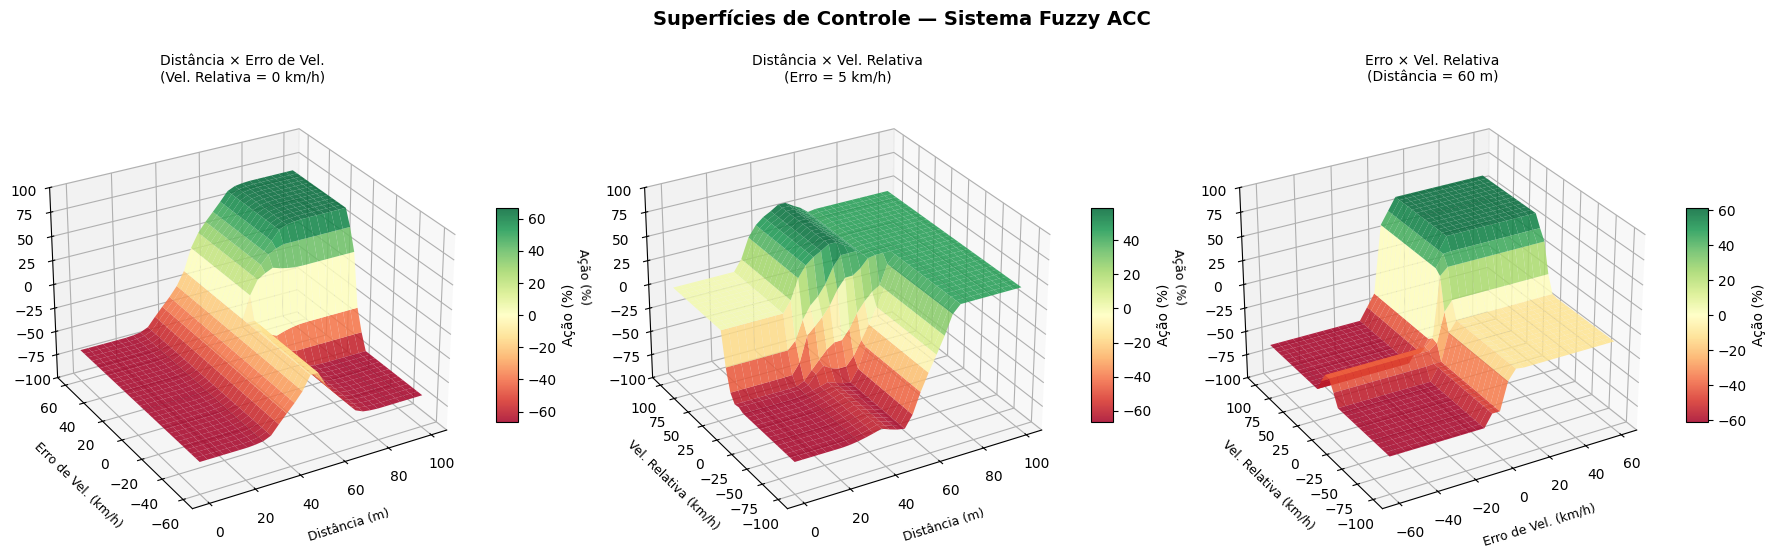

In [15]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ── Re-cria o sistema (caso rode isolado) ──────────────────────────────────────
distancia          = ctrl.Antecedent(np.arange(0, 101, 1),    'distancia')
erro_velocidade    = ctrl.Antecedent(np.arange(-60, 61, 1),   'erro_velocidade')
velocidade_relativa= ctrl.Antecedent(np.arange(-100, 101, 1), 'velocidade_relativa')
acao               = ctrl.Consequent(np.arange(-100, 101, 1), 'acao')

distancia['perto'] = fuzz.trapmf(distancia.universe, [0, 0, 20, 50])
distancia['media'] = fuzz.trimf(distancia.universe,  [30, 50, 70])
distancia['longe'] = fuzz.trapmf(distancia.universe, [50, 80, 100, 100])

erro_velocidade['negativo'] = fuzz.trapmf(erro_velocidade.universe, [-100,-100,-10, 0])
erro_velocidade['zero']     = fuzz.trimf(erro_velocidade.universe,  [-10, 0, 10])
erro_velocidade['positivo'] = fuzz.trapmf(erro_velocidade.universe, [0, 10, 100, 100])

velocidade_relativa['aproximando']  = fuzz.trapmf(velocidade_relativa.universe, [-100,-100,-15, 0])
velocidade_relativa['acompanhando'] = fuzz.trimf(velocidade_relativa.universe,  [-15, 0, 15])
velocidade_relativa['afastando']    = fuzz.trapmf(velocidade_relativa.universe, [0, 15, 100, 100])

acao['frear']    = fuzz.trimf(acao.universe, [-100, -100, 0])
acao['manter']   = fuzz.trimf(acao.universe, [-20, 0, 20])
acao['acelerar'] = fuzz.trimf(acao.universe, [0, 100, 100])

rule1  = ctrl.Rule(distancia['perto'] & velocidade_relativa['aproximando'], acao['frear'])
rule2  = ctrl.Rule(distancia['perto'] & velocidade_relativa['acompanhando'], acao['frear'])
rule3  = ctrl.Rule(distancia['perto'] & velocidade_relativa['afastando'], acao['manter'])
rule4  = ctrl.Rule(distancia['media'] & velocidade_relativa['aproximando'], acao['frear'])
rule5  = ctrl.Rule(distancia['media'] & velocidade_relativa['acompanhando'], acao['manter'])
rule6  = ctrl.Rule(distancia['media'] & velocidade_relativa['afastando'] & erro_velocidade['positivo'], acao['acelerar'])
rule7  = ctrl.Rule(distancia['media'] & velocidade_relativa['afastando'] & erro_velocidade['negativo'], acao['frear'])
rule8  = ctrl.Rule(distancia['longe'] & erro_velocidade['positivo'], acao['acelerar'])
rule9  = ctrl.Rule(distancia['longe'] & erro_velocidade['zero'], acao['manter'])
rule10 = ctrl.Rule(distancia['longe'] & erro_velocidade['negativo'], acao['frear'])

sistema_controle = ctrl.ControlSystem([rule1,rule2,rule3,rule4,rule5,rule6,rule7,rule8,rule9,rule10])
simulador = ctrl.ControlSystemSimulation(sistema_controle)

# ── Funções auxiliares de simulação ───────────────────────────────────────────
ERRO_FIXO      =  5   # km/h  (abaixo da meta → tende a acelerar em via livre)
VEL_REL_FIXA  = -20   # km/h  (aproximando → tende a frear)

def simular_distancia_erro(dist_val, erro_val, vel_rel=0.0):
    """Retorna ação dado (distancia, erro_velocidade) com vel_relativa fixada."""
    try:
        simulador.input['distancia']           = dist_val
        simulador.input['erro_velocidade']     = erro_val
        simulador.input['velocidade_relativa'] = vel_rel
        simulador.compute()
        return simulador.output['acao']
    except Exception:
        return np.nan

def simular_distancia_velrel(dist_val, vel_rel_val, erro=ERRO_FIXO):
    """Retorna ação dado (distancia, velocidade_relativa) com erro fixado."""
    try:
        simulador.input['distancia']           = dist_val
        simulador.input['erro_velocidade']     = erro
        simulador.input['velocidade_relativa'] = vel_rel_val
        simulador.compute()
        return simulador.output['acao']
    except Exception:
        return np.nan

def simular_erro_velrel(erro_val, vel_rel_val, dist=60.0):
    """Retorna ação dado (erro_velocidade, velocidade_relativa) com distancia fixada."""
    try:
        simulador.input['distancia']           = dist
        simulador.input['erro_velocidade']     = erro_val
        simulador.input['velocidade_relativa'] = vel_rel_val
        simulador.compute()
        return simulador.output['acao']
    except Exception:
        return np.nan

# ── Grids ──────────────────────────────────────────────────────────────────────
res = 30   # resolução da malha (aumente para mais detalhe, custa mais tempo)

d_vals   = np.linspace(0,   100, res)
e_vals   = np.linspace(-60,  60, res)
vr_vals  = np.linspace(-100,100, res)

# Superfície 1: Distância × Erro  →  Ação  (vel_relativa = 0)
D1, E1 = np.meshgrid(d_vals, e_vals)
Z1 = np.vectorize(lambda d,e: simular_distancia_erro(d, e, 0.0))(D1, E1)

# Superfície 2: Distância × Vel. Relativa  →  Ação  (erro = ERRO_FIXO)
D2, VR2 = np.meshgrid(d_vals, vr_vals)
Z2 = np.vectorize(lambda d,vr: simular_distancia_velrel(d, vr))(D2, VR2)

# Superfície 3: Erro × Vel. Relativa  →  Ação  (distância = 60 m)
E3, VR3 = np.meshgrid(e_vals, vr_vals)
Z3 = np.vectorize(lambda e,vr: simular_erro_velrel(e, vr, 60.0))(E3, VR3)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 6))
fig.suptitle("Superfícies de Controle — Sistema Fuzzy ACC", fontsize=14, fontweight='bold')

config = [
    # (ax_pos, X,   Y,   Z,  xlabel,              ylabel,           title,                             note)
    (131, D1,  E1,  Z1, 'Distância (m)', 'Erro de Vel. (km/h)',
     'Distância × Erro de Vel.\n(Vel. Relativa = 0 km/h)', ''),
    (132, D2,  VR2, Z2, 'Distância (m)', 'Vel. Relativa (km/h)',
     f'Distância × Vel. Relativa\n(Erro = {ERRO_FIXO} km/h)', ''),
    (133, E3,  VR3, Z3, 'Erro de Vel. (km/h)', 'Vel. Relativa (km/h)',
     'Erro × Vel. Relativa\n(Distância = 60 m)', ''),
]

for pos, X, Y, Z, xl, yl, title, _ in config:
    ax = fig.add_subplot(pos, projection='3d')
    surf = ax.plot_surface(X, Y, Z, cmap='RdYlGn', edgecolor='none', alpha=0.85)
    ax.set_xlabel(xl, fontsize=9, labelpad=8)
    ax.set_ylabel(yl, fontsize=9, labelpad=8)
    ax.set_zlabel('Ação (%)', fontsize=9, labelpad=8)
    ax.set_title(title, fontsize=10)
    ax.set_zlim(-100, 100)
    ax.view_init(elev=28, azim=-120)
    fig.colorbar(surf, ax=ax, shrink=0.4, aspect=10, label='Ação (%)')

plt.tight_layout()
plt.show()

## 📈 Interpretação dos Gráficos de Superfície
 
Como o sistema possui **3 entradas**, cada gráfico fixa uma variável em um valor constante e exibe a relação entre as outras duas e a saída (Ação). Isso gera **3 superfícies complementares**.
 
 
### Gráfico 1 — Distância × Erro de Velocidade
> *Velocidade Relativa fixada em 0 km/h (trânsito estável)*
 
Este gráfico mostra como o sistema decide quando o carro da frente se move à mesma velocidade que o próprio veículo.
 
- **Distância pequena + Erro positivo (abaixo da meta):** mesmo estando abaixo da velocidade alvo, o sistema **freia** — a proximidade do obstáculo tem prioridade sobre a meta de velocidade.
- **Distância grande + Erro positivo:** via livre e abaixo da meta → sistema **acelera**.
- **Transição suave:** em situações intermediárias, o sistema pondera os dois fatores de forma gradual, característica central da lógica fuzzy.

 
### Gráfico 2 — Distância × Velocidade Relativa
> *Erro de Velocidade fixado em +5 km/h (levemente abaixo da meta)*
 
Este gráfico evidencia o impacto do risco de colisão na decisão do sistema.
 
- **Velocidade Relativa negativa (carro da frente freando):** o sistema **freia**, independente da distância atual.
- **Distância grande + Velocidade Relativa positiva (carro da frente se afastando):** situação segura → sistema **acelera**.
- **Queda abrupta:** quando a velocidade relativa fica muito negativa, a reação do sistema é intensa mesmo com distância ainda razoável, refletindo a prioridade de segurança nas regras.
 
### Gráfico 3 — Erro de Velocidade × Velocidade Relativa
> *Distância fixada em 60 m (distância média)*
 
Este gráfico mostra o equilíbrio entre a meta de velocidade e a segurança em relação ao carro da frente.
 
- **Velocidade Relativa negativa + Erro negativo (acima da meta):** situação de duplo risco → sistema aplica **freada máxima**.
- **Velocidade Relativa positiva + Erro positivo (abaixo da meta):** carro da frente se afasta e há espaço para ganhar velocidade → **aceleração máxima**.
- **Região central (platô amarelo):** zona de equilíbrio onde os fatores se cancelam e o sistema tende a **manter a velocidade**.
 
## 🏆 Hierarquia de Prioridades
 
A análise conjunta dos três gráficos revela a hierarquia de prioridades implementada na base de regras:
 
```
Segurança (Velocidade Relativa) > Distância > Meta de Velocidade (Erro)
```
 
Isso é visível porque uma velocidade relativa muito negativa consegue "puxar" a superfície para a zona de frenagem mesmo quando a distância ainda é segura. A lógica fuzzy permite que essa hierarquia seja aplicada de forma **gradual e contínua**, sem transições bruscas entre os estados.
  
## 🗺️ Legenda das Cores
 
| Cor | Significado |
|---|---|
| 🟥 Vermelho | Frear (Ação ≈ −100%) |
| 🟨 Amarelo | Manter velocidade (Ação ≈ 0%) |
| 🟩 Verde | Acelerar (Ação ≈ +100%) |
